In [4]:
import os
import sys
import json
import glob
import pickle
import random

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

sys.path.insert(0, "..")
from scripts.config import BetaVAEConfig
from models.beta_vae import BetaVAE
from data_utils import PreloadedDataset

## Config

In [5]:
CONFIG_PATH  = "config/betavae_full_cfd.json"   # relative to repo root
DATASET_PATH = "datasets/full_cfd_val.pkl"      # relative to repo root
CKPT_PATH    = None   # None → load latest checkpoint from experiment output dir
N_SAMPLES    = 8      # images to show in reconstruction grid
SEED         = 42

random.seed(SEED)
torch.manual_seed(SEED)

## Load model & checkpoint

In [8]:
REPO_ROOT = os.path.abspath("..")

with open(os.path.join(REPO_ROOT, CONFIG_PATH)) as f:
    config = BetaVAEConfig(**json.load(f))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BetaVAE(
    input_channels=config.input_channels,
    input_height=config.input_height,
    input_width=config.input_width,
    latent_dim=config.latent_dim,
    hidden_dim=config.hidden_dim,
    beta=config.beta,
    device=device
)

if CKPT_PATH is None:
    ckpt_dir = os.path.join(REPO_ROOT, config.output_dir, "checkpoints")
    ckpts = glob.glob(os.path.join(ckpt_dir, "*.pt"))
    if not ckpts:
        raise FileNotFoundError(f"No checkpoints found in {ckpt_dir}")
    CKPT_PATH = max(ckpts, key=lambda p: int(p.rsplit("step", 1)[-1].replace(".pt", "")))

ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded: {CKPT_PATH}  (step {ckpt['step']})")

Loaded: /home/jhanliufu/RutishauserLab/DiffusionBANMap/outputs/betavae_full_cfd/checkpoints/betavae_full_cfd_step200.pt  (step 200)


## Reconstructions

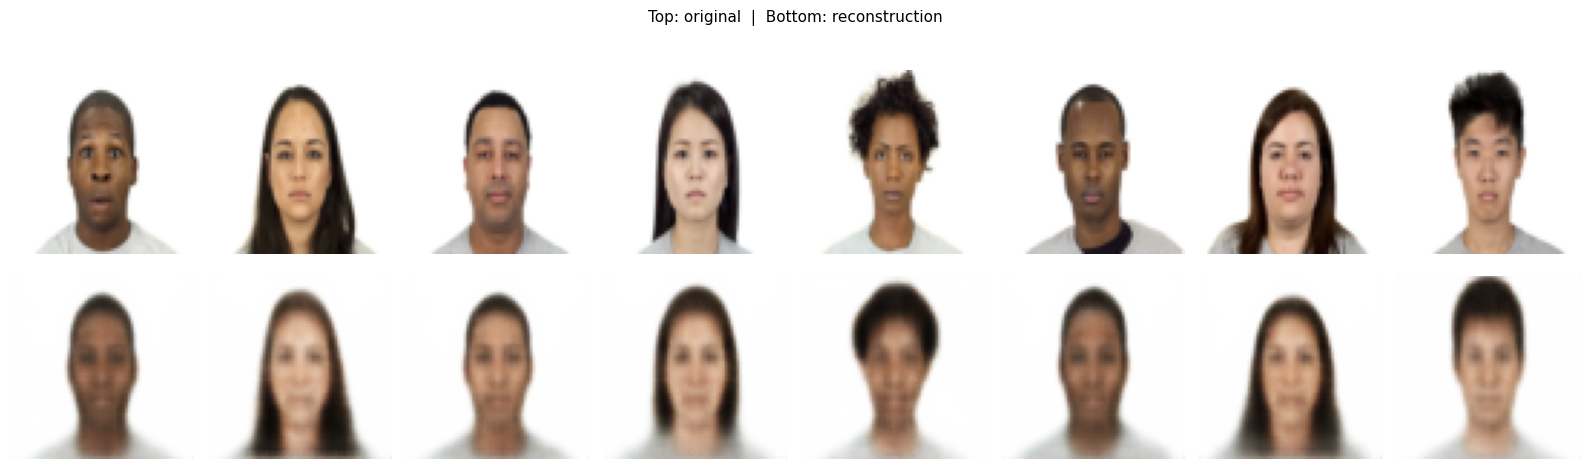

In [9]:
with open(os.path.join(REPO_ROOT, DATASET_PATH), "rb") as f:
    tensor = pickle.load(f)  # [N, C, H, W]

dataset = PreloadedDataset(tensor)

indices = random.sample(range(len(dataset)), min(N_SAMPLES, len(dataset)))
originals = torch.stack([dataset[i] for i in indices]).to(device)

with torch.no_grad():
    x_recon, _, _ = model(originals)
    x_recon = torch.sigmoid(x_recon).cpu()

originals_cpu = originals.cpu()
n = len(indices)

fig, axes = plt.subplots(2, n, figsize=(n * 2, 5))
fig.suptitle("Top: original  |  Bottom: reconstruction", fontsize=11)
for i in range(n):
    axes[0, i].imshow(originals_cpu[i].permute(1, 2, 0))
    axes[0, i].axis("off")
    axes[1, i].imshow(x_recon[i].permute(1, 2, 0))
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

## Latent activation distributions

Pass every image in the dataset through the encoder and collect the posterior mean μ for each latent dimension.

In [10]:
loader = DataLoader(dataset, batch_size=64, shuffle=False)

all_mu = []
with torch.no_grad():
    for batch in loader:
        batch = batch.to(device)
        _, mu, _ = model(batch)
        all_mu.append(mu.cpu())

all_mu = torch.cat(all_mu, dim=0).numpy()  # [N, latent_dim]
print(f"Collected μ for {all_mu.shape[0]} images across {all_mu.shape[1]} latent dimensions")

Collected μ for 120 images across 10 latent dimensions


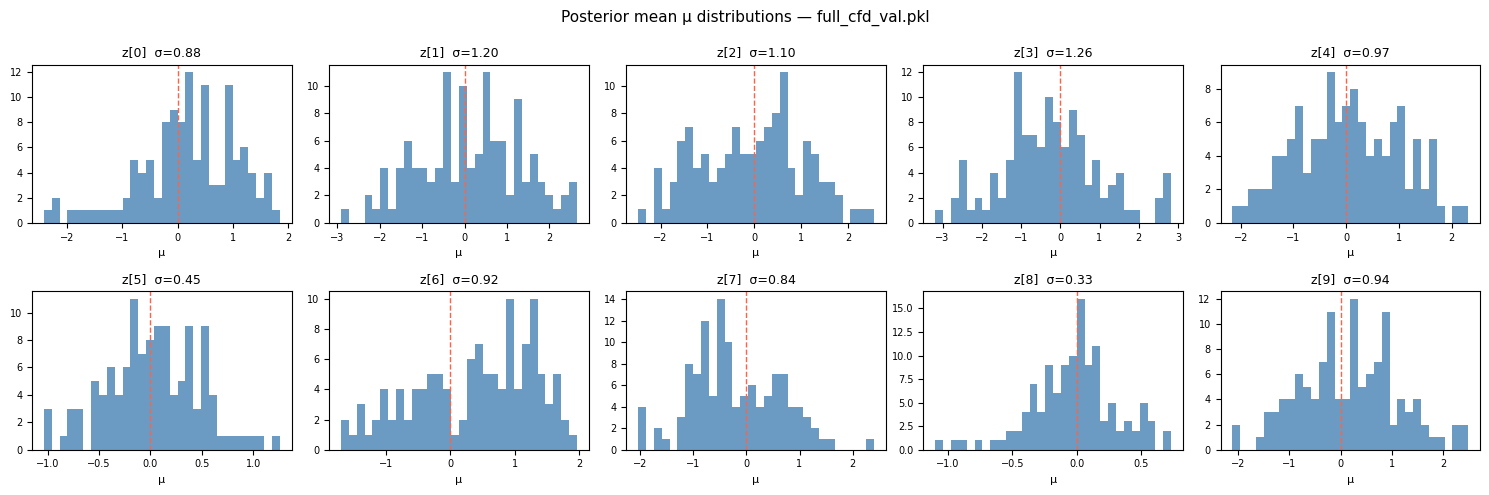

In [11]:
latent_dim = all_mu.shape[1]
ncols = min(5, latent_dim)
nrows = (latent_dim + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2.5))
axes = np.array(axes).flatten()

for i in range(latent_dim):
    axes[i].hist(all_mu[:, i], bins=30, color="steelblue", alpha=0.8, edgecolor="none")
    axes[i].axvline(0, color="tomato", linewidth=1, linestyle="--")
    axes[i].set_title(f"z[{i}]  σ={all_mu[:, i].std():.2f}", fontsize=9)
    axes[i].set_xlabel("μ", fontsize=8)
    axes[i].tick_params(labelsize=7)

for i in range(latent_dim, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(f"Posterior mean μ distributions — {os.path.basename(DATASET_PATH)}", fontsize=11)
plt.tight_layout()
plt.show()